# 04 — ASRS XGBoost Signal Filter

## Goal
Train an XGBoost binary classifier that predicts whether an ASRS trade will be a winner.
Only trade when **P(win) > threshold**, filtering out low-probability setups.

### Pipeline
1. Load the ASRS trade log (`data/asrs_trades_all.csv`) produced by notebook 01.
2. Engineer features from the raw 5-min DAX data (signal bar shape, ATR, gap, morning range, etc.).
3. Train XGBoost with 5-fold stratified cross-validation; tune the probability threshold.
4. Compare filtered vs unfiltered equity curves and walk-forward performance.
5. Save the model for live filtering.

> Baseline (unfiltered): **WR 28.2%, PF 1.08** over 5,135 trades 2006-2026.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import LabelEncoder
try:
    import xgboost as xgb
except ImportError:
    raise ImportError(
        "xgboost is not installed. Run: pip install xgboost  (or: uv add xgboost)"
    )
import joblib
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f'ROOT = {ROOT}')

ROOT = C:\Users\ali\Desktop\Projet-INFO-2AS2


In [2]:
# ── Load trades ──────────────────────────────────────────────────────────────
trades_path = ROOT / 'data' / 'asrs_trades_all.csv'
assert trades_path.exists(), (
    f"Trades file not found: {trades_path}\n"
    "Run notebook 01_asrs_baseline.ipynb first to generate it."
)

trades_raw = pd.read_csv(trades_path, parse_dates=['trade_date'])
trades_df = trades_raw[trades_raw['variant'] == 'ASRS_4th'].copy()
trades_df = trades_df.sort_values('trade_date').reset_index(drop=True)
print(f'Total trades (ASRS_4th): {len(trades_df):,}')
print(f'Date range: {trades_df["trade_date"].min().date()} → {trades_df["trade_date"].max().date()}')

# ── Load raw 5-min data ───────────────────────────────────────────────────────
raw_path = ROOT / 'data' / 'dax-5m_bk.csv'
assert raw_path.exists(), f"Raw data not found: {raw_path}"

raw_df = pd.read_csv(
    raw_path,
    sep=';',
    header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
    dtype={'date': str, 'time': str,
           'open': float, 'high': float, 'low': float,
           'close': float, 'volume': float}
)
raw_df['dt'] = pd.to_datetime(
    raw_df['date'] + ' ' + raw_df['time'],
    format='%d/%m/%Y %H:%M'
)
raw_df = raw_df.sort_values('dt').reset_index(drop=True)
raw_df['date_only'] = raw_df['dt'].dt.date

print(f'\nRaw 5-min rows: {len(raw_df):,}')
print(f'Raw date range: {raw_df["dt"].min()} → {raw_df["dt"].max()}')

Total trades (ASRS_4th): 5,135
Date range: 2006-01-02 → 2026-04-02



Raw 5-min rows: 1,182,771
Raw date range: 2000-06-16 02:50:00 → 2026-04-06 23:50:00


In [3]:
import yfinance as yf

EXT_CACHE = ROOT / 'data' / 'ext_features.csv'

def download_ext_data(start='2005-01-01', end='2026-12-31') -> pd.DataFrame:
    tickers = {'^VIX': 'vix', 'EURUSD=X': 'eurusd', '^GSPC': 'spx'}
    frames = {}
    for ticker, name in tickers.items():
        df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        # yfinance 1.x may return MultiIndex columns
        close = df['Close']
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        close = close.squeeze()
        close.name = name
        close.index = pd.to_datetime(close.index).tz_localize(None).normalize()
        frames[name] = close
    ext = pd.concat(frames.values(), axis=1).sort_index()
    return ext

if EXT_CACHE.exists():
    ext_df = pd.read_csv(EXT_CACHE, index_col=0, parse_dates=True)
    print(f'External data loaded from cache: {len(ext_df):,} rows')
else:
    print('Downloading external data (VIX, EUR/USD, S&P 500)...')
    ext_df = download_ext_data()
    ext_df.to_csv(EXT_CACHE)
    print(f'Saved to cache: {len(ext_df):,} rows')

ext_df['vix_prev']        = ext_df['vix'].shift(1)
ext_df['vix_5d_avg']      = ext_df['vix'].rolling(5).mean().shift(1)
ext_df['vix_5d_change']   = ext_df['vix'].shift(1) - ext_df['vix'].shift(6)
ext_df['spx_prev_ret']    = ext_df['spx'].pct_change().shift(1) * 100
ext_df['eurusd_prev_ret'] = ext_df['eurusd'].pct_change().shift(1) * 100
ext_df['eurusd_5d_ret']   = ext_df['eurusd'].pct_change(5).shift(1) * 100
ext_df.dropna(inplace=True)

print(f'External features: {list(ext_df.columns)}')
print(ext_df.tail(2))

External data loaded from cache: 5,550 rows
External features: ['vix', 'eurusd', 'spx', 'vix_prev', 'vix_5d_avg', 'vix_5d_change', 'spx_prev_ret', 'eurusd_prev_ret', 'eurusd_5d_ret']
              vix    eurusd          spx   vix_prev  vix_5d_avg  \
Date                                                              
2026-04-15  18.17  1.179941  7022.950195  18.360001      19.448   
2026-04-16  18.60  1.177856  7035.189941  18.170000      18.874   

            vix_5d_change  spx_prev_ret  eurusd_prev_ret  eurusd_5d_ret  
Date                                                                     
2026-04-15      -7.420000      1.178287         0.802638       1.972469  
2026-04-16      -2.870001      0.797578         0.259581       0.965182  


In [4]:
def _true_range(df):
    prev_close = df['close'].shift(1)
    return pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev_close).abs(),
        (df['low']  - prev_close).abs(),
    ], axis=1).max(axis=1)


def _is_expiry_week(dt):
    """True if the date is in the week of the 3rd Friday of its month."""
    import calendar
    third_fri = max(
        week[4] for week in calendar.monthcalendar(dt.year, dt.month)
        if week[4] != 0
    )
    third_fri_dt = pd.Timestamp(dt.year, dt.month, third_fri)
    return abs((dt - third_fri_dt).days) <= 4


def _month_end_flag(dt, bdays_in_month):
    """True if dt is in the last 3 business days of its month."""
    return bdays_in_month.get_loc(dt) >= len(bdays_in_month) - 3 if dt in bdays_in_month else False


def build_features(trades_df, raw_df, ext_df):
    raw_df = raw_df.copy()
    raw_df['day'] = pd.to_datetime(raw_df['date_only'])
    grouped = {day: grp.reset_index(drop=True) for day, grp in raw_df.groupby('day')}

    # Daily OHLCV aggregates
    daily = raw_df.groupby('day').agg(
        day_high  = ('high',   'max'),
        day_low   = ('low',    'min'),
        day_close = ('close',  'last'),
        day_open  = ('open',   'first'),
        day_vol   = ('volume', 'sum'),
    ).sort_index()
    daily['prev_close']     = daily['day_close'].shift(1)
    daily['prev_range']     = (daily['day_high'] - daily['day_low']).shift(1)
    daily['prev_close_pos'] = ((daily['day_close'] - daily['day_low']) /
                                (daily['day_high'] - daily['day_low'] + 1e-9)).shift(1)
    daily['prev_day_ret']   = daily['day_close'].pct_change().shift(1) * 100

    # 20-day average morning volume (07:00-09:20 UTC)
    morn_vol = raw_df[
        (raw_df['dt'].dt.hour * 60 + raw_df['dt'].dt.minute >= 7 * 60) &
        (raw_df['dt'].dt.hour * 60 + raw_df['dt'].dt.minute <= 9 * 60 + 20)
    ].groupby('day')['volume'].sum().rolling(20, min_periods=5).mean().shift(1)

    rows = []
    for _, trade in trades_df.iterrows():
        td  = pd.Timestamp(trade['trade_date']).normalize()
        row = {}

        # ── static features from trade ────────────────────────────────────────
        row['sig_range']     = trade['sig_range']
        row['bar_used']      = trade.get('bar_used', 0) or 0
        row['direction_enc'] = 1 if str(trade['direction']).lower() in ('long', 'buy') else 0
        row['dow']           = td.dayofweek
        row['month']         = td.month

        # ── calendar flags ────────────────────────────────────────────────────
        row['is_expiry_week'] = int(_is_expiry_week(td))
        row['week_of_month']  = (td.day - 1) // 7 + 1
        bdays = pd.bdate_range(td.replace(day=1),
                               td + pd.offsets.MonthEnd(0))
        row['is_month_end']   = int(td in bdays and bdays.get_loc(td) >= len(bdays) - 3)
        row['is_month_start'] = int(td in bdays and bdays.get_loc(td) <= 2)

        # ── external features (VIX, SPX, EUR/USD) ────────────────────────────
        ext_row = ext_df[ext_df.index <= td].tail(1)
        if len(ext_row):
            er = ext_row.iloc[0]
            row['vix_prev']        = er['vix_prev']
            row['vix_regime']      = (0 if er['vix_prev'] < 15 else
                                       1 if er['vix_prev'] < 25 else
                                       2 if er['vix_prev'] < 35 else 3)
            row['vix_5d_change']   = er['vix_5d_change']
            row['spx_prev_ret']    = er['spx_prev_ret']
            row['eurusd_prev_ret'] = er['eurusd_prev_ret']
            row['eurusd_5d_ret']   = er['eurusd_5d_ret']
        else:
            for k in ['vix_prev','vix_regime','vix_5d_change',
                      'spx_prev_ret','eurusd_prev_ret','eurusd_5d_ret']:
                row[k] = np.nan

        day_bars = grouped.get(td)
        if day_bars is None or len(day_bars) == 0:
            for k in ['sig_range_norm','bar_body_ratio','wick_upper_ratio',
                      'wick_lower_ratio','bar_bullish','atr14_abs','atr5_abs',
                      'vol_ratio','prev_day_range','prev_close_pos',
                      'prev_day_ret','gap_pts','overnight_ret',
                      'morning_range','morning_direction','morning_vol_ratio',
                      'price_vs_ma20','consecutive_up']:
                row[k] = np.nan
            row['winner'] = 1 if trade['pnl'] > 0 else 0
            rows.append(row)
            continue

        # ── locate signal bar at 09:15 ────────────────────────────────────────
        sig_mask = day_bars['dt'].dt.hour * 60 + day_bars['dt'].dt.minute == 9*60+15
        sig_bars = day_bars[sig_mask]
        sig_bar  = sig_bars.iloc[0] if len(sig_bars) else None
        sig_idx  = sig_bars.index[0] if len(sig_bars) else None

        pre_bars = day_bars.loc[:sig_idx] if sig_idx is not None else day_bars
        tr       = _true_range(pre_bars)
        atr14    = tr.rolling(14, min_periods=1).mean().iloc[-1]
        atr5     = tr.rolling(5,  min_periods=1).mean().iloc[-1]
        ma20     = pre_bars['close'].rolling(20, min_periods=1).mean().iloc[-1]

        row['atr14_abs']    = atr14
        row['atr5_abs']     = atr5
        row['vol_ratio']    = atr5 / atr14 if atr14 > 0 else 1.0   # >1 = expanding vol
        row['sig_range_norm'] = trade['sig_range'] / atr14 if atr14 > 0 else np.nan

        # signal bar shape
        if sig_bar is not None:
            sig_o, sig_h, sig_l, sig_c = sig_bar['open'], sig_bar['high'], sig_bar['low'], sig_bar['close']
            r = sig_h - sig_l
            d = r if r > 0 else 1.0
            row['bar_body_ratio']   = abs(sig_c - sig_o) / d
            row['wick_upper_ratio'] = (sig_h - max(sig_o, sig_c)) / d
            row['wick_lower_ratio'] = (min(sig_o, sig_c) - sig_l) / d
            row['bar_bullish']      = 1 if sig_c > sig_o else 0
            row['price_vs_ma20']    = (sig_c - ma20) / atr14 if atr14 > 0 else 0.0
        else:
            row['bar_body_ratio'] = row['wick_upper_ratio'] = row['wick_lower_ratio'] = np.nan
            row['bar_bullish']    = row['price_vs_ma20'] = np.nan

        # daily context
        if td in daily.index:
            d_row = daily.loc[td]
            row['prev_day_range']  = d_row['prev_range']
            row['prev_close_pos']  = d_row['prev_close_pos']
            row['prev_day_ret']    = d_row['prev_day_ret']
            prev_close             = d_row['prev_close']
        else:
            row['prev_day_range'] = row['prev_close_pos'] = row['prev_day_ret'] = np.nan
            prev_close = np.nan

        # gap & overnight return
        open_900 = day_bars[day_bars['dt'].dt.hour*60+day_bars['dt'].dt.minute == 9*60]
        if len(open_900) and not np.isnan(prev_close):
            row['gap_pts']      = open_900.iloc[0]['open'] - prev_close
            row['overnight_ret']= (open_900.iloc[0]['open'] / prev_close - 1) * 100 if prev_close else np.nan
        else:
            row['gap_pts'] = row['overnight_ret'] = np.nan

        # morning range & direction (09:00-09:15)
        morn = day_bars[(day_bars['dt'].dt.hour*60+day_bars['dt'].dt.minute >= 9*60) &
                        (day_bars['dt'].dt.hour*60+day_bars['dt'].dt.minute <= 9*60+15)]
        if len(morn) >= 1:
            row['morning_range']     = morn['high'].max() - morn['low'].min()
            row['morning_direction'] = np.sign(morn.iloc[-1]['close'] - morn.iloc[0]['open'])
        else:
            row['morning_range'] = row['morning_direction'] = np.nan

        # morning volume ratio
        today_morn_vol = day_bars[
            (day_bars['dt'].dt.hour*60+day_bars['dt'].dt.minute >= 7*60) &
            (day_bars['dt'].dt.hour*60+day_bars['dt'].dt.minute <= 9*60+20)
        ]['volume'].sum()
        avg_morn = morn_vol.get(td, np.nan)
        row['morning_vol_ratio'] = today_morn_vol / avg_morn if avg_morn and avg_morn > 0 else np.nan

        # consecutive up/down days
        past_days = sorted([d for d in daily.index if d < td])[-5:]
        consec = 0
        if len(past_days) >= 2:
            rets = [daily.loc[d, 'prev_day_ret'] for d in past_days if d in daily.index]
            last_sign = np.sign(rets[-1]) if rets else 0
            for r_val in reversed(rets):
                if np.sign(r_val) == last_sign:
                    consec += 1
                else:
                    break
        row['consecutive_up'] = consec * (1 if len(past_days) > 0 and
                                           daily.loc[past_days[-1], 'prev_day_ret'] > 0
                                           else -1) if consec > 0 else 0

        row['winner'] = 1 if trade['pnl'] > 0 else 0
        rows.append(row)

    feat_df = pd.DataFrame(rows).reset_index(drop=True).ffill().fillna(0)
    feat_df['trade_date']   = trades_df['trade_date'].values
    feat_df['pnl']          = trades_df['pnl'].values
    feat_df['initial_risk'] = trades_df['initial_risk'].values
    return feat_df


print('build_features() v2 defined — 30+ features including VIX, EUR/USD, S&P500, calendar.')

build_features() v2 defined — 30+ features including VIX, EUR/USD, S&P500, calendar.


In [5]:
print('Building feature matrix (2-3 min on 5k trades)...')
features_df = build_features(trades_df, raw_df, ext_df)

print(f'\nFeature matrix shape: {features_df.shape}')

FEATURE_COLS = [
    # Signal bar
    'sig_range', 'sig_range_norm', 'bar_body_ratio',
    'wick_upper_ratio', 'wick_lower_ratio', 'bar_bullish', 'bar_used',
    # Volatility
    'atr14_abs', 'atr5_abs', 'vol_ratio',
    # Market context (DAX price)
    'prev_day_range', 'prev_close_pos', 'prev_day_ret',
    'gap_pts', 'overnight_ret',
    # Morning session
    'morning_range', 'morning_direction', 'morning_vol_ratio',
    'price_vs_ma20',
    # External (VIX, SPX, EUR/USD)
    'vix_prev', 'vix_regime', 'vix_5d_change',
    'spx_prev_ret', 'eurusd_prev_ret', 'eurusd_5d_ret',
    # Calendar
    'dow', 'month', 'week_of_month',
    'is_expiry_week', 'is_month_end', 'is_month_start',
    # Trade meta
    'direction_enc', 'consecutive_up',
]

n_win  = (features_df['winner'] == 1).sum()
n_loss = (features_df['winner'] == 0).sum()
print(f'\nClass balance:  Winners {n_win:,} ({100*n_win/len(features_df):.1f}%)  |  Losers {n_loss:,} ({100*n_loss/len(features_df):.1f}%)')

print('\nFeature correlations with winner (|r| sorted):')
corr = features_df[FEATURE_COLS + ['winner']].corr()['winner'].drop('winner').sort_values(key=abs, ascending=False)
for feat, val in corr.head(20).items():
    bar = '█' * int(abs(val) * 200)
    print(f'  {feat:<25} {val:+.4f}  {bar}')

Building feature matrix (2-3 min on 5k trades)...



Feature matrix shape: (5135, 37)

Class balance:  Winners 1,450 (28.2%)  |  Losers 3,685 (71.8%)

Feature correlations with winner (|r| sorted):
  sig_range_norm            +0.1334  ██████████████████████████
  bar_body_ratio            +0.0788  ███████████████
  wick_upper_ratio          -0.0715  ██████████████
  vol_ratio                 +0.0655  █████████████
  direction_enc             +0.0548  ██████████
  bar_bullish               +0.0469  █████████
  prev_day_range            -0.0442  ████████
  atr14_abs                 -0.0405  ████████
  vix_regime                -0.0395  ███████
  vix_5d_change             -0.0359  ███████
  sig_range                 +0.0289  █████
  consecutive_up            +0.0274  █████
  wick_lower_ratio          -0.0265  █████
  vix_prev                  -0.0227  ████
  atr5_abs                  -0.0222  ████
  gap_pts                   +0.0178  ███
  overnight_ret             +0.0168  ███
  morning_range             -0.0165  ███
  spx_prev_ret       

In [6]:
# ── Volatility regimes based on ATR14 ────────────────────────────────────────
features_df['vol_regime'] = pd.qcut(
    features_df['atr14_abs'], q=3, labels=['low', 'mid', 'high']
)

print('Trade count and win rate per volatility regime:')
print(f'{"Regime":<8}  {"N trades":>9}  {"Win Rate":>9}  {"Avg ATR14":>10}')
print('-' * 42)
for regime in ['low', 'mid', 'high']:
    mask = features_df['vol_regime'] == regime
    n = mask.sum()
    wr = features_df.loc[mask, 'winner'].mean() * 100
    avg_atr = features_df.loc[mask, 'atr14_abs'].mean()
    print(f'{regime:<8}  {n:>9,}  {wr:>8.1f}%  {avg_atr:>10.1f}')

print('\nNote: vol_regime will be combined with the winner label for stratified CV')
print('to ensure each fold has balanced volatility representation.')

Trade count and win rate per volatility regime:
Regime     N trades   Win Rate   Avg ATR14
------------------------------------------
low           1,712      30.7%         8.8
mid           1,711      28.3%        14.3
high          1,712      25.8%        25.5

Note: vol_regime will be combined with the winner label for stratified CV
to ensure each fold has balanced volatility representation.


In [7]:
FEATURES = FEATURE_COLS
TARGET   = 'winner'
THRESHOLD = 0.40

X = features_df[FEATURES].values
y = features_df[TARGET].values

# Combine vol regime + winner label for stratification
strat_labels = (
    features_df['vol_regime'].astype(str) + '_' + features_df[TARGET].astype(str)
)

scale_pos = (y == 0).sum() / max((y == 1).sum(), 1)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold cross-validation...')
oof_probs = cross_val_predict(
    model, X, y,
    cv=cv,
    method='predict_proba',
)[:, 1]

overall_auc = roc_auc_score(y, oof_probs)
print(f'\nOverall OOF AUC: {overall_auc:.4f}')

print('\nPer-fold AUC:')
fold_aucs = []
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, strat_labels)):
    fold_auc = roc_auc_score(y[val_idx], oof_probs[val_idx])
    fold_aucs.append(fold_auc)
    n_val = len(val_idx)
    wr_val = y[val_idx].mean() * 100
    print(f'  Fold {fold_idx+1}: AUC={fold_auc:.4f}  (N={n_val}, WR={wr_val:.1f}%)')
print(f'  Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

Running 5-fold cross-validation...



Overall OOF AUC: 0.5778

Per-fold AUC:
  Fold 1: AUC=0.6003  (N=1027, WR=28.2%)
  Fold 2: AUC=0.5489  (N=1027, WR=28.2%)
  Fold 3: AUC=0.5720  (N=1027, WR=28.2%)
  Fold 4: AUC=0.5816  (N=1027, WR=28.1%)
  Fold 5: AUC=0.5864  (N=1027, WR=28.3%)
  Mean AUC: 0.5778 ± 0.0171


In [8]:
# ── Threshold analysis ────────────────────────────────────────────────────────
thresholds = np.arange(0.30, 0.70, 0.05)

all_pnl  = features_df['pnl'].values
all_wins = features_df['winner'].values

total_pf_baseline = all_pnl[all_pnl > 0].sum() / abs(all_pnl[all_pnl < 0].sum())
total_wr_baseline = all_wins.mean() * 100

print(f'Baseline (no filter):')
print(f'  N={len(all_pnl):,}  WR={total_wr_baseline:.1f}%  PF={total_pf_baseline:.3f}  PnL={all_pnl.sum():+.0f}')
print()

header = f'{"Threshold":>9} {"N kept":>8} {"Filtered%":>10} {"WR%":>7} {"PF":>7} {"Total PnL":>11}'
print(header)
print('-' * len(header))

results = []
for thr in thresholds:
    keep = oof_probs >= thr
    n_kept = keep.sum()
    if n_kept == 0:
        continue
    pnl_kept  = all_pnl[keep]
    wins_kept = all_wins[keep]
    wr  = wins_kept.mean() * 100
    gross_win  = pnl_kept[pnl_kept > 0].sum()
    gross_loss = abs(pnl_kept[pnl_kept < 0].sum())
    pf  = gross_win / gross_loss if gross_loss > 0 else np.inf
    total_pnl = pnl_kept.sum()
    filt_pct  = (1 - n_kept / len(all_pnl)) * 100
    print(f'{thr:>9.2f} {n_kept:>8,} {filt_pct:>9.1f}% {wr:>6.1f}% {pf:>7.3f} {total_pnl:>+11.0f}')
    results.append({'threshold': thr, 'n_kept': n_kept, 'wr': wr, 'pf': pf, 'total_pnl': total_pnl})

results_df = pd.DataFrame(results)

# Best threshold: highest PF with >= 200 trades remaining
valid = results_df[results_df['n_kept'] >= 200]
if len(valid) > 0:
    best_row = valid.loc[valid['pf'].idxmax()]
    BEST_THRESHOLD = best_row['threshold']
    print(f'\nBest threshold (PF-maximising, N>=200): {BEST_THRESHOLD:.2f}')
    print(f'  N={int(best_row["n_kept"]):,}  WR={best_row["wr"]:.1f}%  PF={best_row["pf"]:.3f}  PnL={best_row["total_pnl"]:+.0f}')
else:
    BEST_THRESHOLD = THRESHOLD
    print(f'No threshold with N>=200 found; using default {BEST_THRESHOLD}')

Baseline (no filter):
  N=5,135  WR=28.2%  PF=1.082  PnL=+6029

Threshold   N kept  Filtered%     WR%      PF   Total PnL
---------------------------------------------------------
     0.30    4,151      19.2%   29.7%   1.071       +4218
     0.35    3,687      28.2%   30.5%   1.079       +4132
     0.40    3,041      40.8%   31.5%   1.107       +4623
     0.45    2,383      53.6%   32.8%   1.108       +3606
     0.50    1,770      65.5%   35.4%   1.212       +5086
     0.55    1,170      77.2%   37.5%   1.278       +4299
     0.60      690      86.6%   40.0%   1.407       +3562
     0.65      372      92.8%   40.3%   1.378       +1795

Best threshold (PF-maximising, N>=200): 0.60
  N=690  WR=40.0%  PF=1.407  PnL=+3562


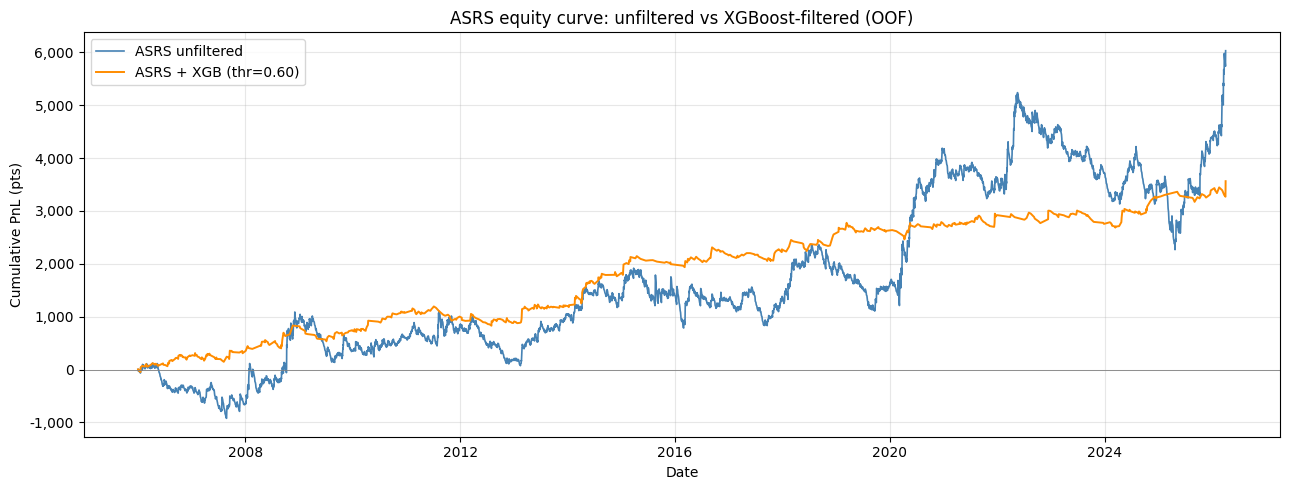


Unfiltered:  N=5,135  PnL=+6029
Filtered:    N=690  PnL=+3562


In [9]:
# ── Equity curves: filtered vs unfiltered ────────────────────────────────────
filter_mask = oof_probs >= BEST_THRESHOLD

pnl_all      = features_df['pnl'].values
pnl_filtered = np.where(filter_mask, pnl_all, 0.0)

cum_all      = np.cumsum(pnl_all)
cum_filtered = np.cumsum(pnl_filtered[filter_mask])   # only active trades
dates_all    = pd.to_datetime(features_df['trade_date'])
dates_filt   = dates_all[filter_mask]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_all,  cum_all,      linewidth=1.2, label='ASRS unfiltered', color='steelblue')
ax.plot(dates_filt, cum_filtered, linewidth=1.4, label=f'ASRS + XGB (thr={BEST_THRESHOLD:.2f})', color='darkorange')
ax.axhline(0, color='grey', linewidth=0.6)
ax.set_title('ASRS equity curve: unfiltered vs XGBoost-filtered (OOF)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL (pts)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f'\nUnfiltered:  N={len(pnl_all):,}  PnL={cum_all[-1]:+.0f}')
print(f'Filtered:    N={filter_mask.sum():,}  PnL={cum_filtered[-1] if len(cum_filtered)>0 else 0:+.0f}')

Fitting final model on full dataset...


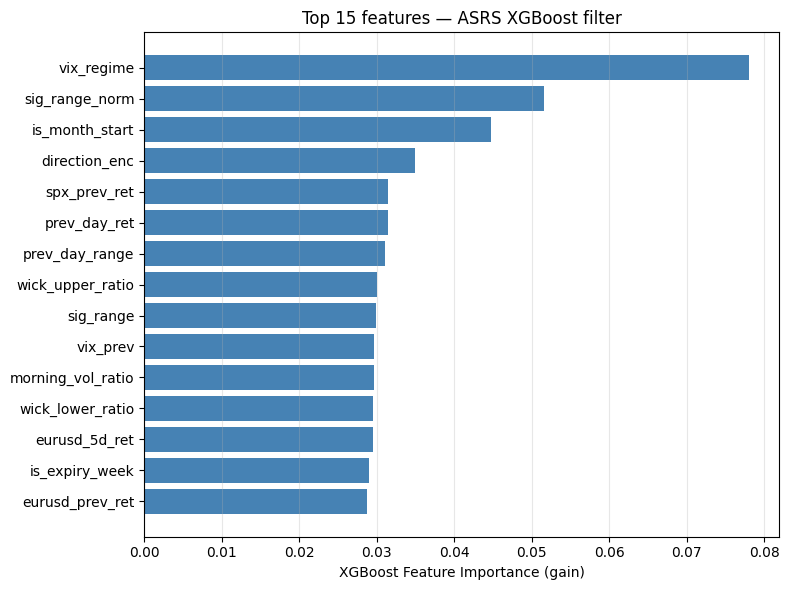


Top 15 features:
Rank  Feature                     Importance
--------------------------------------------
1     vix_regime                     0.07803
2     sig_range_norm                 0.05153
3     is_month_start                 0.04470
4     direction_enc                  0.03495
5     spx_prev_ret                   0.03150
6     prev_day_ret                   0.03144
7     prev_day_range                 0.03109
8     wick_upper_ratio               0.03009
9     sig_range                      0.02990
10    vix_prev                       0.02966
11    morning_vol_ratio              0.02964
12    wick_lower_ratio               0.02954
13    eurusd_5d_ret                  0.02945
14    is_expiry_week                 0.02901
15    eurusd_prev_ret                0.02878


In [10]:
# ── Feature importance: fit on full dataset ───────────────────────────────────
print('Fitting final model on full dataset...')
model.fit(X, y)

importances = model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue')
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title('Top 15 features — ASRS XGBoost filter')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(f'{"Rank":<5} {"Feature":<25} {"Importance":>12}')
print('-' * 44)
for rank, (_, row) in enumerate(feat_imp_df.iterrows(), 1):
    print(f'{rank:<5} {row["feature"]:<25} {row["importance"]:>12.5f}')

In [11]:
# ── Performance by volatility regime ─────────────────────────────────────────
def regime_stats(mask, label):
    pnl   = features_df.loc[mask, 'pnl'].values
    wins  = features_df.loc[mask, 'winner'].values
    if len(pnl) == 0:
        return f'{label:<20} {0:>8}  {0:>7.1f}%  {0:>7.3f}  {0:>+12.0f}'
    wr   = wins.mean() * 100
    gw   = pnl[pnl > 0].sum()
    gl   = abs(pnl[pnl < 0].sum())
    pf   = gw / gl if gl > 0 else np.inf
    tot  = pnl.sum()
    return f'{label:<20} {len(pnl):>8,}  {wr:>7.1f}%  {pf:>7.3f}  {tot:>+12.0f}'

print(f'{"Label":<20} {"N":>8}  {"WR":>7}  {"PF":>7}  {"PnL":>12}')
print('-' * 62)

for regime in ['low', 'mid', 'high']:
    regime_mask = features_df['vol_regime'] == regime
    filt_and_regime = regime_mask & filter_mask

    print(regime_stats(regime_mask,          f'{regime.upper()} VOL unfilt'))
    print(regime_stats(filt_and_regime,       f'{regime.upper()} VOL filtered'))
    print()

Label                       N       WR       PF           PnL
--------------------------------------------------------------
LOW VOL unfilt          1,712     30.7%    1.119         +1743
LOW VOL filtered          304     41.1%    1.660         +1668

MID VOL unfilt          1,711     28.3%    1.000            -5
MID VOL filtered          253     39.9%    1.406         +1361

HIGH VOL unfilt         1,712     25.8%    1.116         +4291
HIGH VOL filtered         133     37.6%    1.185          +533



In [12]:
# ── Walk-forward validation: train 2006-2019, test 2020-2026 ─────────────────
TRAIN_END = pd.Timestamp('2019-12-31')
TEST_START = pd.Timestamp('2020-01-01')

dates = pd.to_datetime(features_df['trade_date'])
train_mask = dates <= TRAIN_END
test_mask  = dates >= TEST_START

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train set (2006-2019): {train_mask.sum():,} trades')
print(f'Test  set (2020-2026): {test_mask.sum():,} trades')

# Refit on train only
scale_pos_train = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
wf_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos_train,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
wf_model.fit(X_train, y_train)
wf_probs_test = wf_model.predict_proba(X_test)[:, 1]

wf_filter = wf_probs_test >= BEST_THRESHOLD
pnl_test_all   = features_df.loc[test_mask, 'pnl'].values
wins_test_all  = features_df.loc[test_mask, 'winner'].values
pnl_test_filt  = pnl_test_all[wf_filter]
wins_test_filt = wins_test_all[wf_filter]

def pf(pnl_arr):
    gw = pnl_arr[pnl_arr > 0].sum()
    gl = abs(pnl_arr[pnl_arr < 0].sum())
    return gw / gl if gl > 0 else np.inf

print()
print('Walk-Forward results (test period 2020-2026):')
print(f'{"":<22} {"N":>7} {"WR%":>7} {"PF":>7} {"PnL":>11}')
print('-' * 56)
print(f'{"ASRS unfiltered":<22} '
      f'{len(pnl_test_all):>7,} '
      f'{wins_test_all.mean()*100:>6.1f}% '
      f'{pf(pnl_test_all):>7.3f} '
      f'{pnl_test_all.sum():>+11.0f}')
if len(pnl_test_filt) > 0:
    print(f'{"ASRS + XGB filter":<22} '
          f'{len(pnl_test_filt):>7,} '
          f'{wins_test_filt.mean()*100:>6.1f}% '
          f'{pf(pnl_test_filt):>7.3f} '
          f'{pnl_test_filt.sum():>+11.0f}')
else:
    print('No trades passed filter on test set.')

if len(pnl_test_all) > 0 and len(pnl_test_filt) > 0:
    test_auc = roc_auc_score(y_test, wf_probs_test)
    print(f'\nWalk-forward test AUC: {test_auc:.4f}')

Train set (2006-2019): 3,541 trades
Test  set (2020-2026): 1,594 trades



Walk-Forward results (test period 2020-2026):
                             N     WR%      PF         PnL
--------------------------------------------------------
ASRS unfiltered          1,594   27.5%   1.151       +4445
ASRS + XGB filter          162   30.9%   1.059        +186

Walk-forward test AUC: 0.5491


In [13]:
# ── Save model ────────────────────────────────────────────────────────────────
model.fit(X, y)
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(model,    models_dir / 'asrs_xgb_filter.pkl')
joblib.dump(FEATURES, models_dir / 'asrs_xgb_features.pkl')
print(f'Model saved  → models/asrs_xgb_filter.pkl')
print(f'Features     → models/asrs_xgb_features.pkl')
print(f'Threshold    : {BEST_THRESHOLD:.2f}')
print(f'OOF AUC      : {overall_auc:.4f}')
print(f'\nTo load:')
print("  model    = joblib.load('models/asrs_xgb_filter.pkl')")
print("  features = joblib.load('models/asrs_xgb_features.pkl')")
print("  prob = model.predict_proba(X_new)[0, 1]")
print(f"  trade = prob >= {BEST_THRESHOLD:.2f}")

Model saved  → models/asrs_xgb_filter.pkl
Features     → models/asrs_xgb_features.pkl
Threshold    : 0.60
OOF AUC      : 0.5778

To load:
  model    = joblib.load('models/asrs_xgb_filter.pkl')
  features = joblib.load('models/asrs_xgb_features.pkl')
  prob = model.predict_proba(X_new)[0, 1]
  trade = prob >= 0.60


In [14]:
# ── Rule-based filter : VIX regime + sig_range_norm ──────────────────────────
# Sweep combinaisons de seuils sur les 2 features les plus importantes

print('=== Rule-Based Filter : VIX + sig_range_norm ===\n')
print(f'Baseline  N={len(features_df):,}  WR={features_df["winner"].mean()*100:.1f}%  '
      f'PF={features_df["pnl"][features_df["pnl"]>0].sum()/abs(features_df["pnl"][features_df["pnl"]<0].sum()):.3f}  '
      f'PnL={features_df["pnl"].sum():+.0f}\n')

vix_thresholds   = [15, 20, 25]          # max VIX accepté
range_thresholds = [0.5, 0.7, 0.9, 1.1]  # min sig_range_norm

print(f'{"VIX<":>6}  {"rng_norm>":>10}  {"N":>6}  {"WR%":>6}  {"PF":>7}  {"PnL":>9}  {"vs baseline":>12}')
print('-' * 70)

best = {'pf': 0, 'label': ''}
for vix_max in vix_thresholds:
    for rng_min in range_thresholds:
        mask = (features_df['vix_prev'] < vix_max) & (features_df['sig_range_norm'] > rng_min)
        pnl  = features_df.loc[mask, 'pnl'].values
        wins = features_df.loc[mask, 'winner'].values
        if len(pnl) < 50:
            continue
        wr  = wins.mean() * 100
        gw  = pnl[pnl > 0].sum()
        gl  = abs(pnl[pnl < 0].sum())
        pf  = gw / gl if gl > 0 else np.inf
        tot = pnl.sum()
        delta = tot - features_df['pnl'].sum()
        print(f'{vix_max:>6}  {rng_min:>10.1f}  {len(pnl):>6,}  {wr:>5.1f}%  {pf:>7.3f}  {tot:>+9.0f}  {delta:>+12.0f}')
        if pf > best['pf']:
            best = {'pf': pf, 'vix_max': vix_max, 'rng_min': rng_min,
                    'n': len(pnl), 'wr': wr, 'pnl': tot, 'label': f'VIX<{vix_max} & rng>{rng_min}'}
    print()

print(f'\nBest rule : {best["label"]}')
print(f'  N={best["n"]:,}  WR={best["wr"]:.1f}%  PF={best["pf"]:.3f}  PnL={best["pnl"]:+.0f}')

# ── Walk-forward avec le meilleur rule ───────────────────────────────────────
print('\n=== Walk-Forward Rule-Based (train 2006-2019 → test 2020-2026) ===\n')
dates = pd.to_datetime(features_df['trade_date'])
test_mask = dates >= pd.Timestamp('2020-01-01')

for vix_max, rng_min in [(best['vix_max'], best['rng_min']), (25, 0.7)]:
    rule = (features_df['vix_prev'] < vix_max) & (features_df['sig_range_norm'] > rng_min)
    filt_test = rule & test_mask
    pnl_t = features_df.loc[test_mask, 'pnl'].values
    pnl_f = features_df.loc[filt_test, 'pnl'].values
    wins_t = features_df.loc[test_mask, 'winner'].values
    wins_f = features_df.loc[filt_test, 'winner'].values
    if len(pnl_f) == 0:
        continue
    pf_base = pnl_t[pnl_t>0].sum() / abs(pnl_t[pnl_t<0].sum())
    pf_filt = pnl_f[pnl_f>0].sum() / abs(pnl_f[pnl_f<0].sum()) if abs(pnl_f[pnl_f<0].sum()) > 0 else np.inf
    print(f'Rule VIX<{vix_max} & rng_norm>{rng_min}:')
    print(f'  Unfiltered  N={len(pnl_t):,}  WR={wins_t.mean()*100:.1f}%  PF={pf_base:.3f}  PnL={pnl_t.sum():+.0f}')
    print(f'  Filtered    N={len(pnl_f):,}  WR={wins_f.mean()*100:.1f}%  PF={pf_filt:.3f}  PnL={pnl_f.sum():+.0f}')
    print()

=== Rule-Based Filter : VIX + sig_range_norm ===

Baseline  N=5,135  WR=28.2%  PF=1.082  PnL=+6029

  VIX<   rng_norm>       N     WR%       PF        PnL   vs baseline
----------------------------------------------------------------------
    15         0.5   1,710   30.7%    1.032       +598         -5431
    15         0.7   1,477   32.0%    1.045       +742         -5287
    15         0.9   1,040   36.2%    1.147      +1770         -4259
    15         1.1     650   38.0%    1.120       +957         -5072

    20         0.5   3,295   29.0%    1.003       +125         -5904
    20         0.7   2,830   30.5%    1.003       +124         -5905
    20         0.9   2,002   34.0%    1.061      +1613         -4416
    20         1.1   1,255   35.9%    1.041       +716         -5313

    25         0.5   4,169   29.1%    1.068      +3708         -2321
    25         0.7   3,587   30.5%    1.066      +3190         -2839
    25         0.9   2,551   33.7%    1.092      +3267         -2762

In [15]:
# ── Ce que le modèle a appris sur le range ───────────────────────────────────
# Le backtest inclut TOUS les trades (range 1→200 pts), sans filtre F2.
# On analyse si le XGBoost retrouve les bornes 10-55, ou en trouve de meilleures.

print('=== Analyse du range par le modèle XGBoost ===\n')
print('(Le backtest inclut tous les trades, pas seulement range 10-55)\n')

# Probabilité moyenne prédite par bucket de range
features_df['range_bucket'] = pd.cut(
    features_df['sig_range'],
    bins=[0, 5, 10, 15, 20, 30, 40, 55, 70, 100, 500],
    labels=['0-5','5-10','10-15','15-20','20-30','30-40','40-55','55-70','70-100','100+']
)

# Fit model on full dataset to get probabilities
model.fit(X, y)
all_probs = model.predict_proba(X)[:, 1]
features_df['xgb_prob'] = all_probs

grp = features_df.groupby('range_bucket', observed=True).agg(
    n        = ('pnl', 'count'),
    wr       = ('winner', lambda x: x.mean() * 100),
    avg_pnl  = ('pnl', 'mean'),
    avg_prob = ('xgb_prob', 'mean'),
    total_pnl= ('pnl', 'sum'),
).round(2)

print(f'{"Bucket":>8}  {"N":>6}  {"WR%":>6}  {"AvgPnL":>8}  {"XGB prob":>9}  {"TotalPnL":>10}')
print('-' * 58)
for bucket, row in grp.iterrows():
    f2_flag = ' ← F2' if str(bucket) in ['10-15','15-20','20-30','30-40','40-55'] else ''
    print(f'{str(bucket):>8}  {int(row["n"]):>6,}  {row["wr"]:>5.1f}%  '
          f'{row["avg_pnl"]:>+8.1f}  {row["avg_prob"]:>9.3f}  {row["total_pnl"]:>+10.0f}{f2_flag}')

# Trouver les bornes optimales selon le modèle vs F2 hardcodé
print('\n--- Comparaison des filtres ---')
f2_mask   = (features_df['sig_range'] >= 10) & (features_df['sig_range'] <= 55)
xgb_mask  = features_df['xgb_prob'] >= 0.50

for label, mask in [('F2 hardcodé (10-55)', f2_mask),
                     ('XGBoost prob>0.50', xgb_mask),
                     ('F2 ET XGBoost>0.50', f2_mask & xgb_mask)]:
    pnl  = features_df.loc[mask, 'pnl'].values
    wins = features_df.loc[mask, 'winner'].values
    if len(pnl) == 0: continue
    gw = pnl[pnl>0].sum(); gl = abs(pnl[pnl<0].sum())
    pf = gw/gl if gl > 0 else np.inf
    print(f'  {label:<28} N={len(pnl):>5,}  WR={wins.mean()*100:.1f}%  PF={pf:.3f}  PnL={pnl.sum():+.0f}')

=== Analyse du range par le modèle XGBoost ===

(Le backtest inclut tous les trades, pas seulement range 10-55)



  Bucket       N     WR%    AvgPnL   XGB prob    TotalPnL
----------------------------------------------------------
     0-5     174   25.3%      +0.4      0.400         +75
    5-10   1,234   24.7%      -0.2      0.410        -278
   10-15   1,381   27.9%      +0.2      0.450        +248 ← F2
   15-20     917   31.5%      +2.6      0.490       +2389 ← F2
   20-30     916   28.8%      +1.0      0.460        +904 ← F2
   30-40     312   34.3%     +12.6      0.480       +3936 ← F2
   40-55     126   29.4%      +5.0      0.470        +632 ← F2
   55-70      45   22.2%     -19.7      0.400        -888
  70-100      23   34.8%     -19.2      0.430        -441
    100+       7   14.3%     -78.2      0.350        -547

--- Comparaison des filtres ---
  F2 hardcodé (10-55)          N=3,657  WR=29.6%  PF=1.138  PnL=+8038
  XGBoost prob>0.50            N=1,931  WR=64.9%  PF=4.963  PnL=+53544
  F2 ET XGBoost>0.50           N=1,512  WR=63.7%  PF=4.778  PnL=+45356
